# Reddit Labeled Data EDA (Modeling Preparation)

Dataset: `data/processed/REDDIT MEDIA/reddit_labels_checkpoint.jsonl`

Objective: Validate label quality, coverage, and feature readiness before predictive modeling.

## 1) Load Data and Inspect Structure

We start with a raw structural check: row count, column names, types, and a sample of records.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path(r"D:/SCRIPTS/FX-AlphaLab/data/processed/REDDIT MEDIA/reddit_labels_checkpoint.jsonl")
print("File exists:", DATA_PATH.exists())
print("File size (MB):", round(DATA_PATH.stat().st_size / (1024**2), 2) if DATA_PATH.exists() else None)

df = pd.read_json(DATA_PATH, lines=True)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

File exists: True
File size (MB): 27.99
Shape: (25458, 16)

Columns:
['id', 'subreddit', 'title', 'body', 'flair', 'score', 'created_utc', 'reasoning', 'content_type', 'sarcasm_irony_score', 'sentiment_strength', 'target_pair', 'risk_sentiment', 'target_clarity', 'stance_clarity', 'model']


,id,subreddit,title,body,flair,score,created_utc,reasoning,content_type,sarcasm_irony_score,sentiment_strength,target_pair,risk_sentiment,target_clarity,stance_clarity,model
0,1dg08oi,Forex,Prop firm challenge pass + account management ...,So i was surfing through net looking for some ...,Prop Firms,0,1718396363,"NOISE: question about prop firm services, no m...",NOISE,0,0,None,NEUTRAL,0,QUESTION,unknown
1,1k6d22q,investing,Do the graham rules still apply to the current...,The rules (in part) for the uninitiated \n\n1....,,18,1745449197,"FUNDAMENTAL: asks if Graham rules apply, no ma...",FUNDAMENTAL,0,0,None,NEUTRAL,0,QUESTION,unknown
2,wg0mpf,stocks,How liquid should one be?,"Two questions here. First, I here some people ...",Advice,0,1659617917,"NOISE: personal liquidity advice request, no m...",NOISE,0,0,None,NEUTRAL,0,QUESTION,unknown


In [2]:
# Quick dtype and null profile
schema_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2)
}).sort_values("null_pct", ascending=False)

display(schema_df)
print("\nDuplicate rows:", int(df.duplicated().sum()))

,dtype,non_null,nulls,null_pct
target_pair,object,2274,23184,91.07
id,object,25458,0,0.00
title,object,25458,0,0.00
subreddit,object,25458,0,0.00
flair,object,25458,0,0.00
score,int64,25458,0,0.00
created_utc,int64,25458,0,0.00
body,object,25458,0,0.00
reasoning,object,25458,0,0.00
content_type,object,25458,0,0.00



Duplicate rows: 0


**Dataset is structurally complete except for target currency pair labels.**

The table shows 25,458 rows, 16 columns, zero full-row duplicates, and zero nulls in all columns except `target_pair`.
`target_pair` is missing in 23,184 rows (91.07%), which means pair-specific modeling will have low coverage unless we model only a subset or add target inference.
This immediately suggests two modeling tracks: a broad generic signal model and a narrower pair-specific model.

## 2) Time Coverage and Posting Dynamics

Now we check the temporal span and posting intensity to ensure labels are not concentrated in a narrow period.

In [3]:
df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", utc=True)
df["date"] = df["created_dt"].dt.date

date_counts = df.groupby("date").size().rename("post_count").to_frame()
print("Date min:", df["created_dt"].min())
print("Date max:", df["created_dt"].max())
print("Unique days:", date_counts.shape[0])
print("Median posts/day:", int(date_counts["post_count"].median()))
print("95th pct posts/day:", int(date_counts["post_count"].quantile(0.95)))

display(date_counts.describe().T)

Date min: 2021-01-01 00:24:14+00:00
Date max: 2025-12-31 23:42:15+00:00
Unique days: 1826
Median posts/day: 13
95th pct posts/day: 27


,count,mean,std,min,25%,50%,75%,max
post_count,1826.0,13.94195,7.050652,1.0,9.0,13.0,18.0,53.0


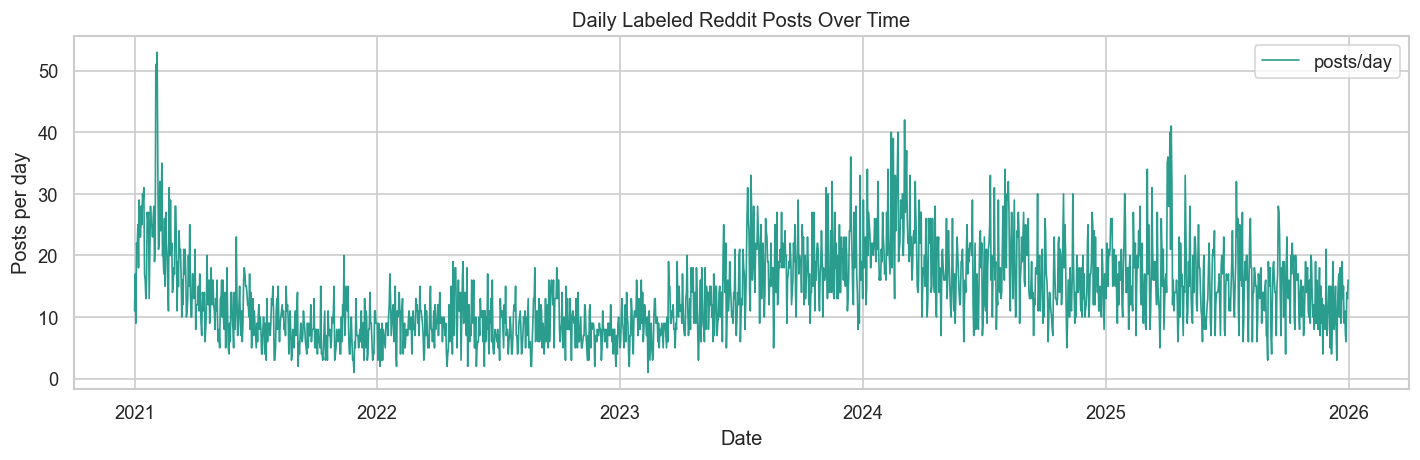

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
date_counts["post_count"].plot(ax=ax, color="#2a9d8f", linewidth=1)
ax.set_title("Daily Labeled Reddit Posts Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Posts per day")
ax.legend(["posts/day"])
plt.tight_layout()
plt.show()

**Coverage spans exactly 5 years with moderate daily volume and clear regime shifts.**

The dataset runs from 2021-01-01 to 2025-12-31 across 1,826 unique days, with a median of 13 posts/day and a max of 53.
The plot shows elevated activity in early 2021, a quieter 2021-2022 period, then a step-up from mid-2023 onward before softening in late 2025.
For modeling, this suggests non-stationarity in posting intensity, so time-aware validation (rolling splits) is safer than random splits.

**Coverage spans exactly 5 years with moderate daily volume and clear regime shifts.**

The dataset runs from 2021-01-01 to 2025-12-31 across 1,826 unique days, with a median of 13 posts/day and a max of 53.
The plot shows elevated activity in early 2021, a quieter 2021-2022 period, then a step-up from mid-2023 onward before softening in late 2025.
For modeling, this suggests non-stationarity in posting intensity, so time-aware validation (rolling splits) is safer than random splits.

## 3) Label Distributions and Potential Imbalance

We now test whether target labels are balanced enough for supervised learning.

In [5]:
dist_content = df["content_type"].value_counts(dropna=False)
dist_risk = df["risk_sentiment"].value_counts(dropna=False)
dist_stance = df["stance_clarity"].value_counts(dropna=False)

print("Content type distribution (%):")
display((dist_content / len(df) * 100).round(2).rename("pct"))

print("Risk sentiment distribution (%):")
display((dist_risk / len(df) * 100).round(2).rename("pct"))

print("Stance clarity distribution (%):")
display((dist_stance / len(df) * 100).round(2).rename("pct"))

Content type distribution (%):


content_type
NOISE                  75.80
FUNDAMENTAL             8.18
TECHNICAL               7.68
POSITION_DISCLOSURE     7.14
NEWS_REACTION           1.21
Name: pct, dtype: float64

Risk sentiment distribution (%):


risk_sentiment
NEUTRAL     95.08
RISK_OFF     3.52
RISK_ON      1.40
Name: pct, dtype: float64

Stance clarity distribution (%):


stance_clarity
QUESTION       72.11
NONE           19.57
CLEAR           7.81
CONDITIONAL     0.51
Name: pct, dtype: float64

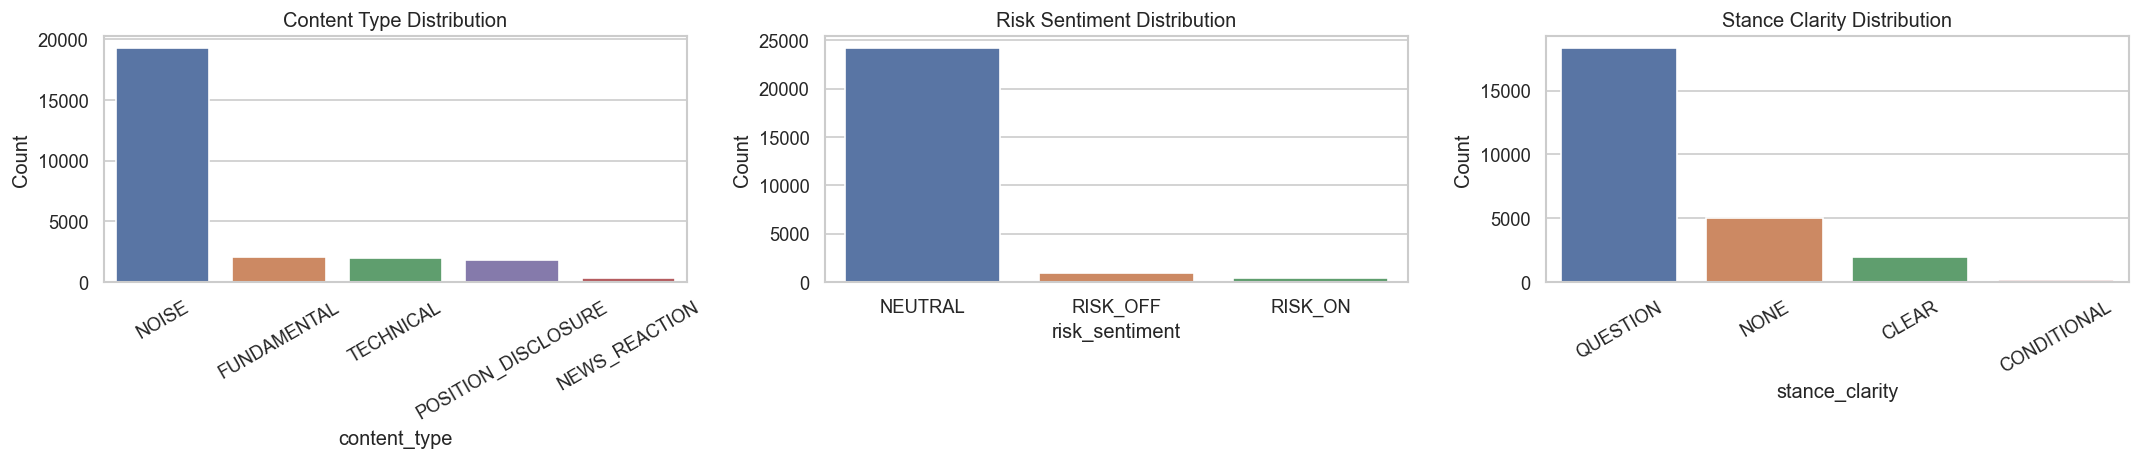

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="content_type", order=dist_content.index, ax=axes[0], hue="content_type", legend=False)
axes[0].set_title("Content Type Distribution")
axes[0].set_xlabel("content_type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="risk_sentiment", order=dist_risk.index, ax=axes[1], hue="risk_sentiment", legend=False)
axes[1].set_title("Risk Sentiment Distribution")
axes[1].set_xlabel("risk_sentiment")
axes[1].set_ylabel("Count")

sns.countplot(data=df, x="stance_clarity", order=dist_stance.index, ax=axes[2], hue="stance_clarity", legend=False)
axes[2].set_title("Stance Clarity Distribution")
axes[2].set_xlabel("stance_clarity")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Label space is heavily imbalanced, especially for risk sentiment and content type.**

`NOISE` dominates content labeling (75.80%), while `NEUTRAL` dominates risk sentiment (95.08%).
For stance, `QUESTION` is 72.11% and truly actionable classes (`CLEAR`, `CONDITIONAL`) are rare.
This means naive accuracy would be misleading; any modeling step should use class-aware metrics (macro-F1, balanced accuracy) and likely class weighting or resampling.

## 4) Numeric Feature Quality and Outliers

We inspect numeric label fields and engagement (`score`) for scaling and outlier behavior.

In [7]:
numeric_cols = ["score", "sarcasm_irony_score", "sentiment_strength", "target_clarity"]
summary_num = df[numeric_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

display(summary_num)

for c in numeric_cols:
    zero_pct = (df[c] == 0).mean() * 100
    print(f"{c}: % zeros = {zero_pct:.2f}")

,count,mean,std,min,50%,90%,95%,99%,max
score,25458.0,57.471679,739.469808,0.0,2.0,51.0,153.0,993.43,88310.0
sarcasm_irony_score,25458.0,0.019287,0.171361,0.0,0.0,0.0,0.0,1.00,2.0
sentiment_strength,25458.0,0.011352,0.373837,-2.0,0.0,0.0,0.0,2.00,2.0
target_clarity,25458.0,0.164663,0.535048,0.0,0.0,0.0,2.0,2.00,2.0


score: % zeros = 19.68
sarcasm_irony_score: % zeros = 98.59
sentiment_strength: % zeros = 94.58
target_clarity: % zeros = 90.97


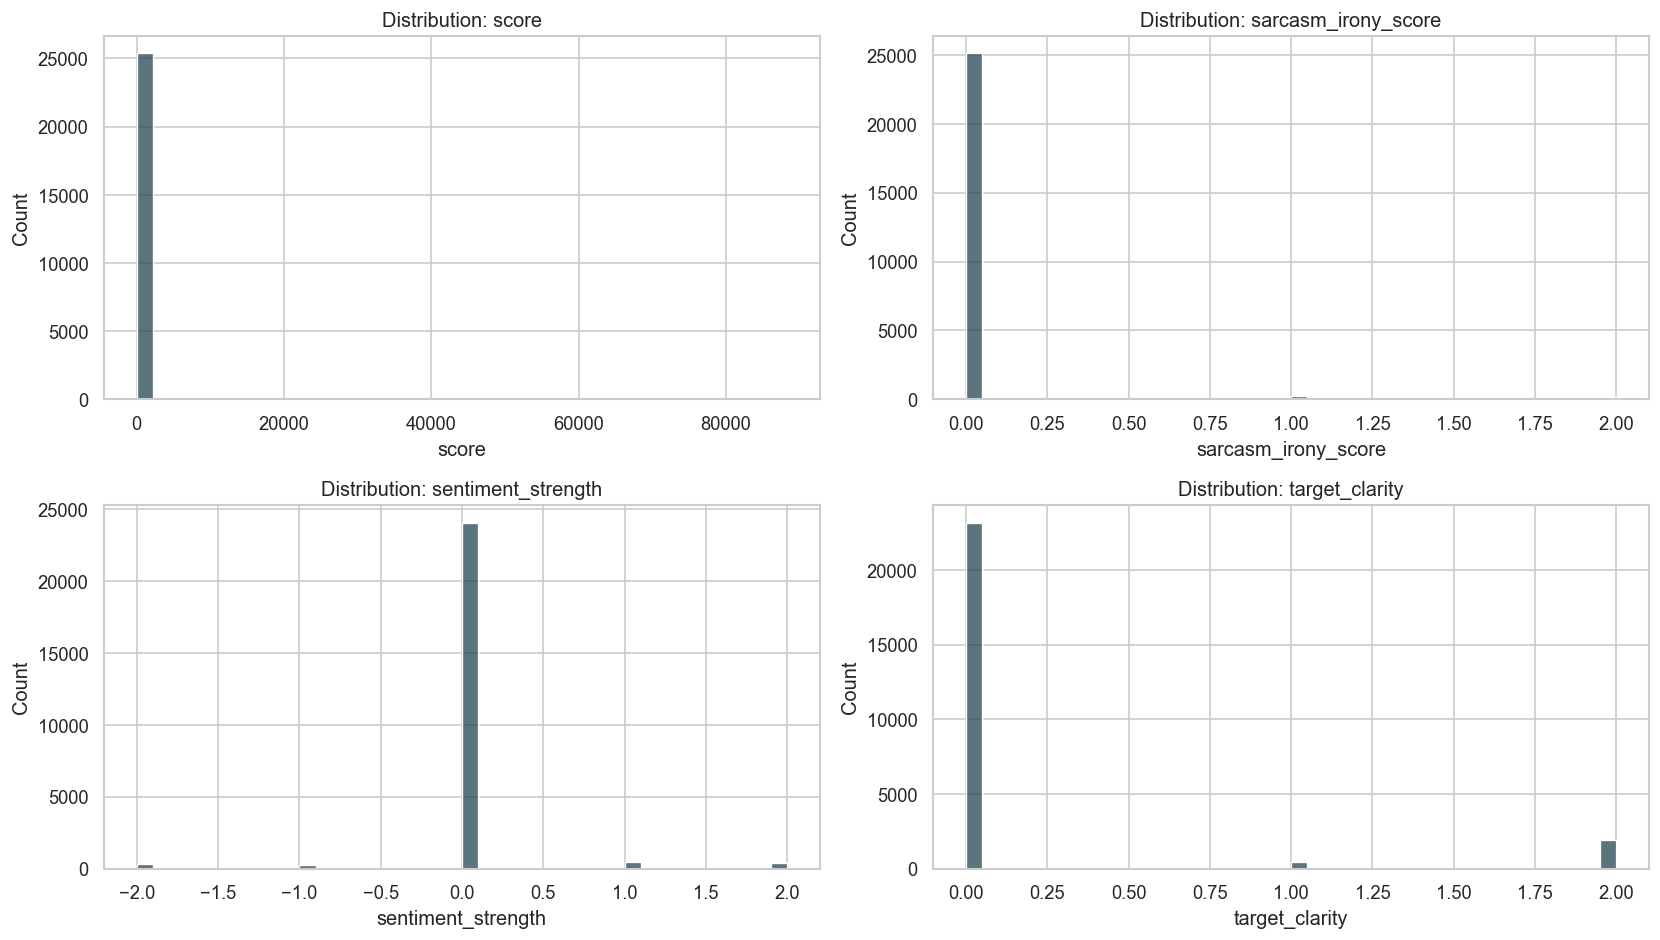

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, kde=False, ax=axes[i], color="#264653")
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Most numeric fields are zero-inflated, and engagement is extremely heavy-tailed.**

`score` has median 2 but max 88,310, indicating viral outliers that can dominate means and linear losses.
The label-derived numerics are mostly zeros: sarcasm (98.59% zero), sentiment_strength (94.58% zero), and target_clarity (90.97% zero).
For modeling, robust transforms (`log1p` for score), quantile clipping, and potentially two-stage targets (zero vs non-zero, then magnitude) are more appropriate than plain regression assumptions.

## 5) Cross-Label Relationships and Source Segmentation

Now we examine where non-neutral and non-noise labels appear by subreddit and by label interactions.

In [9]:
top_subs = df["subreddit"].value_counts().head(12)
print("Top subreddits by volume:")
display(top_subs.rename("count"))

ct_content_risk = pd.crosstab(df["content_type"], df["risk_sentiment"], normalize="index").round(3)
print("\nRisk sentiment within each content type (row-normalized):")
display(ct_content_risk)

Top subreddits by volume:


subreddit
Forex        12729
investing     6365
stocks        6364
Name: count, dtype: int64


Risk sentiment within each content type (row-normalized):


risk_sentiment,NEUTRAL,RISK_OFF,RISK_ON
content_type,,,
FUNDAMENTAL,0.631,0.284,0.085
NEWS_REACTION,0.524,0.319,0.156
NOISE,0.991,0.007,0.002
POSITION_DISCLOSURE,0.952,0.023,0.025
TECHNICAL,0.962,0.016,0.022


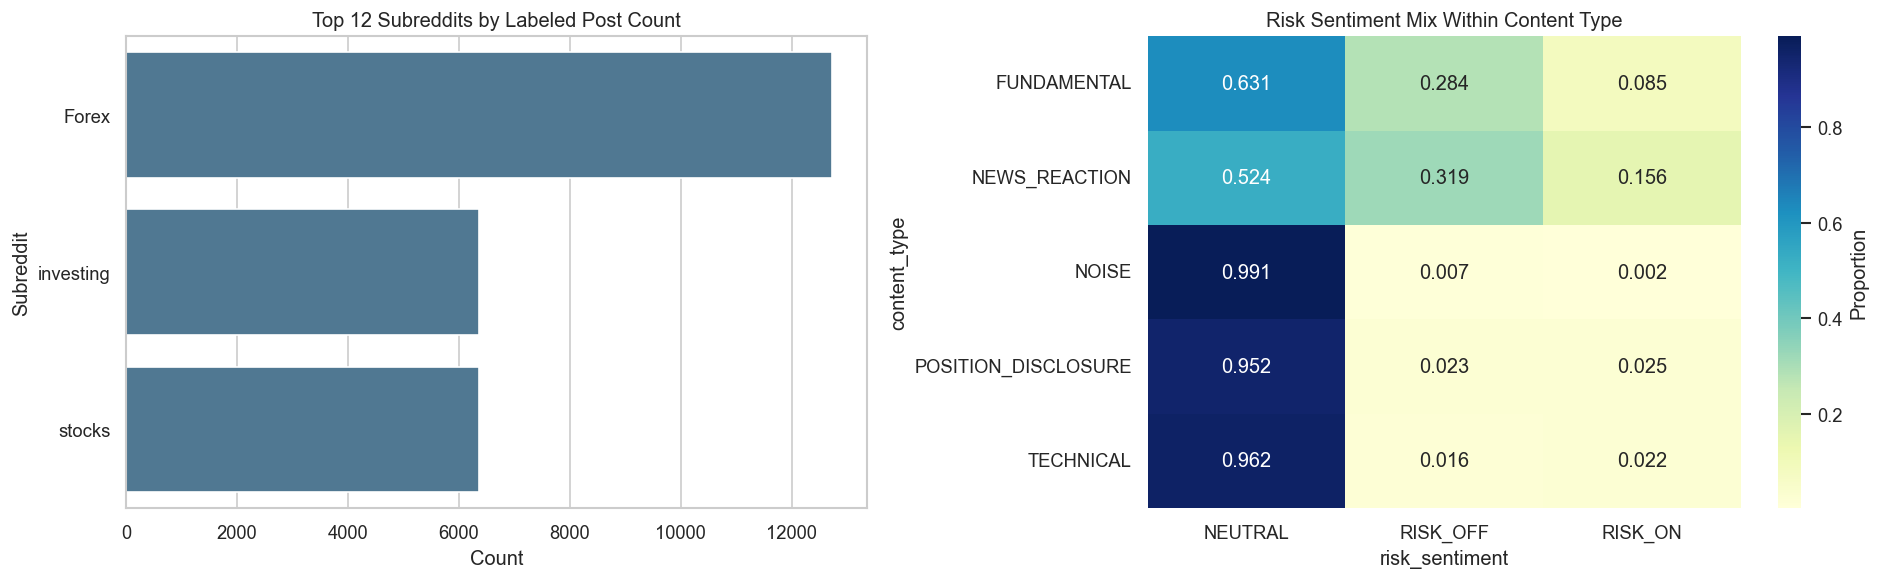

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_subs.values, y=top_subs.index, ax=axes[0], color="#457b9d")
axes[0].set_title("Top 12 Subreddits by Labeled Post Count")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Subreddit")

sns.heatmap(ct_content_risk, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Proportion"})
axes[1].set_title("Risk Sentiment Mix Within Content Type")
axes[1].set_xlabel("risk_sentiment")
axes[1].set_ylabel("content_type")

plt.tight_layout()
plt.show()

**Signal-rich labels are concentrated in specific content types, while NOISE is almost always neutral.**

The dataset is sourced from only three subreddits, with `Forex` contributing about half the rows.
`NOISE` has 99.1% neutral risk sentiment, but `FUNDAMENTAL` and `NEWS_REACTION` contain far larger non-neutral shares (RISK_OFF/RISK_ON).
This suggests a filtering strategy before modeling risk sentiment: prioritize or reweight `FUNDAMENTAL` and `NEWS_REACTION` for higher information density.

## 6) Target Pair Coverage for FX-Specific Modeling

Because downstream signal extraction is FX-oriented, we check how many rows contain an explicit `target_pair` and what those pairs are.

In [11]:
pair_df = df[df["target_pair"].notna()].copy()
print("Rows with target_pair:", pair_df.shape[0])
print("Coverage %:", round(pair_df.shape[0] / len(df) * 100, 2))
print("Unique pairs:", pair_df["target_pair"].nunique())

top_pairs = pair_df["target_pair"].value_counts().head(15)
display(top_pairs.rename("count"))

pair_risk = pd.crosstab(pair_df["target_pair"], pair_df["risk_sentiment"], normalize="index").round(3)
display(pair_risk.head(10))

Rows with target_pair: 2274
Coverage %: 8.93
Unique pairs: 121


target_pair
EURUSD    469
XAUUSD    312
GBPUSD    223
USDJPY    164
USD       160
GBPJPY    111
AUDUSD     89
USDCAD     66
USDCHF     49
JPY        41
EURGBP     36
NZDUSD     35
GBPAUD     30
EURJPY     28
EUR        27
Name: count, dtype: int64

risk_sentiment,NEUTRAL,RISK_OFF,RISK_ON
target_pair,,,
ARS,1.000,0.000,0.000
ARSUSD,0.000,0.000,1.000
AUD,0.857,0.143,0.000
AUDCAD,0.875,0.000,0.125
AUDCHF,0.800,0.000,0.200
"AUDCHF,EURCHF",1.000,0.000,0.000
AUDGBP,1.000,0.000,0.000
AUDJPY,0.864,0.045,0.091
AUDNZD,0.941,0.000,0.059


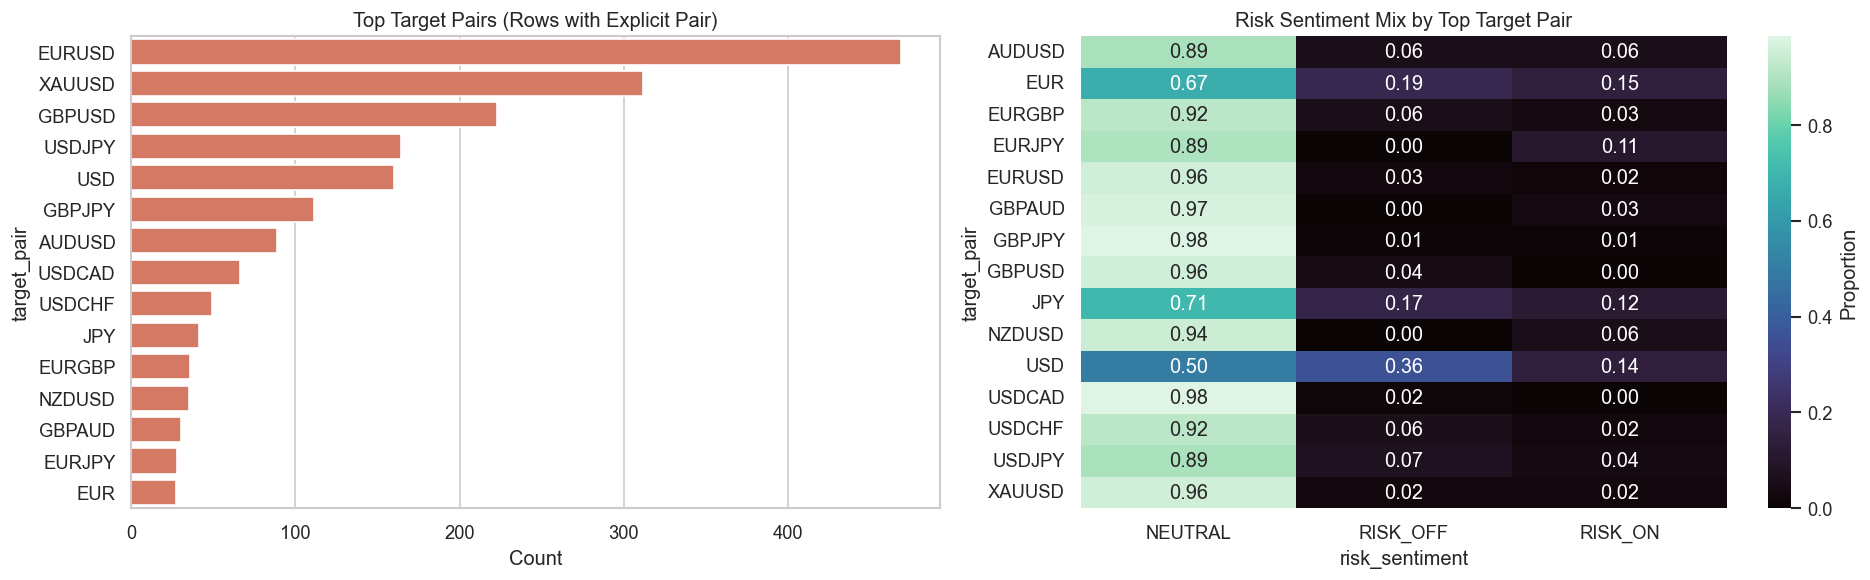

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_pairs.values, y=top_pairs.index, ax=axes[0], color="#e76f51")
axes[0].set_title("Top Target Pairs (Rows with Explicit Pair)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("target_pair")

pair_risk_top = pair_df[pair_df["target_pair"].isin(top_pairs.index)]
pair_risk_top = pd.crosstab(pair_risk_top["target_pair"], pair_risk_top["risk_sentiment"], normalize="index")
sns.heatmap(pair_risk_top, annot=True, fmt=".2f", cmap="mako", ax=axes[1], cbar_kws={"label": "Proportion"})
axes[1].set_title("Risk Sentiment Mix by Top Target Pair")
axes[1].set_xlabel("risk_sentiment")
axes[1].set_ylabel("target_pair")

plt.tight_layout()
plt.show()

**FX-specific modeling is feasible but only on a small labeled subset.**

Only 2,274 rows (8.93%) include `target_pair`, spread across 121 distinct pair strings, many of which are sparse.
Top pairs (EURUSD, XAUUSD, GBPUSD, USDJPY) dominate this subset, while pair-level risk sentiment is still mostly neutral.
A practical approach is to start pair-specific models on high-support pairs only, while using full-dataset models for generic risk/content classification.

## 7) Labeling Metadata and Text-Length Sanity Check

Before modeling, we validate labeling metadata consistency and raw text length distribution.

In [13]:
df["text_len"] = (df["title"].fillna("") + " " + df["body"].fillna("")).str.len()

print("Model field distribution:")
display(df["model"].value_counts(dropna=False).rename("count"))

print("\nReasoning non-empty %:", round((df["reasoning"].str.len() > 0).mean() * 100, 2))
print("Text length summary:")
display(df["text_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Model field distribution:


model
qwen/qwen3-14b              23781
unknown                      1539
gemma-4-26b-a4b-it             69
openai/gpt-oss-120b            48
meta-llama/llama-4-scout       21
Name: count, dtype: int64


Reasoning non-empty %: 100.0
Text length summary:


count    25458.000000
mean       731.691531
std       1304.416906
min         20.000000
50%        428.000000
90%       1439.000000
95%       2237.150000
99%       6020.870000
max      38681.000000
Name: text_len, dtype: float64

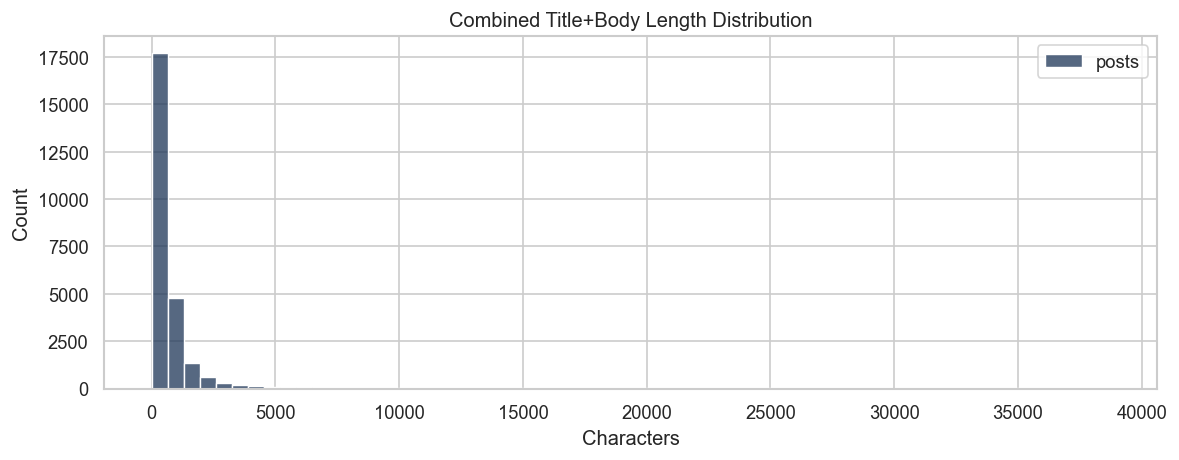

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["text_len"], bins=60, ax=ax, color="#1d3557")
ax.set_title("Combined Title+Body Length Distribution")
ax.set_xlabel("Characters")
ax.set_ylabel("Count")
ax.legend(["posts"])
plt.tight_layout()
plt.show()

**Labeling metadata is mostly consistent, and text length has a strong long tail.**

Most rows were labeled by `qwen/qwen3-14b` (23,781), with smaller portions from `unknown` and other models, so model-source shift should be monitored during evaluation.
All rows include non-empty `reasoning`, which is useful for auditability and potential weak-supervision features.
Text length is highly skewed (median 428, 99th percentile 6,021, max 38,681), so truncation policy and length-aware batching will matter for transformer training efficiency.

## Summary of Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Dataset has 25,458 rows over 2021-2025 with no duplicate rows and only one heavily missing field (`target_pair` 91.07% null). | Build two pipelines: full-corpus generic classifier and smaller pair-specific models. |
| 2 | Core labels are imbalanced (`NOISE` 75.80%, `NEUTRAL` 95.08%, `QUESTION` 72.11%). | Use class-aware metrics, class weighting, and likely resampling; avoid raw accuracy as primary KPI. |
| 3 | Numeric signals are sparse/zero-inflated and engagement is heavy-tailed (`score` max 88,310 vs median 2). | Apply robust transforms/clipping and consider two-stage objectives (zero vs non-zero, then magnitude). |
| 4 | Non-neutral risk signal concentrates in `FUNDAMENTAL`/`NEWS_REACTION`, while `NOISE` is almost always neutral. | Pre-filter or reweight by content type to increase information density for sentiment modeling. |
| 5 | Only 2,274 rows (8.93%) have explicit target pairs, with top pairs dominating and many rare pair strings. | Start FX pair-specific experiments on high-support pairs (e.g., EURUSD, XAUUSD, GBPUSD, USDJPY) before expanding. |
| 6 | Text length is long-tailed and label provenance is multi-model but dominated by one model (`qwen/qwen3-14b`). | Define truncation policy, test robustness to length, and track label-source effects in validation splits. |

## 8) Statistical Linkage to FX Markets (No Modeling)

This section tests whether Reddit-derived aggregates have measurable relationships with next-day FX/metal returns.
We use daily aggregation, lead/lag correlations, and non-parametric/parametric group tests.

In [15]:
from scipy import stats

FX_DIR = Path(r"D:/SCRIPTS/FX-AlphaLab/data/processed/ohlcv")

def choose_d1_file(symbol: str) -> Path | None:
    candidates = sorted(FX_DIR.glob(f"ohlcv_{symbol}_D1_*.parquet"))
    if not candidates:
        candidates = sorted(FX_DIR.glob(f"ohlcv_{symbol}m_D1_*.parquet"))
    return candidates[-1] if candidates else None

symbols = ["EURUSD", "GBPUSD", "USDJPY", "XAUUSD"]
selected_files = {s: choose_d1_file(s) for s in symbols}
print("Selected OHLCV files:")
for k, v in selected_files.items():
    print(f"{k}: {v.name if v else 'NOT FOUND'}")

Selected OHLCV files:
EURUSD: ohlcv_EURUSD_D1_2003-05-04_2025-12-31.parquet
GBPUSD: ohlcv_GBPUSD_D1_2003-05-04_2025-12-31.parquet
USDJPY: ohlcv_USDJPY_D1_2003-05-04_2025-12-31.parquet
XAUUSD: ohlcv_XAUUSDm_D1_2021-01-03_2025-12-30.parquet


In [16]:
# Build Reddit daily features
reddit_daily = (
    df.assign(
        risk_on=(df["risk_sentiment"] == "RISK_ON").astype(int),
        risk_off=(df["risk_sentiment"] == "RISK_OFF").astype(int),
        non_neutral=(df["risk_sentiment"] != "NEUTRAL").astype(int),
        non_noise=(df["content_type"] != "NOISE").astype(int),
    )
    .groupby("date", as_index=False)
    .agg(
        posts=("id", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        risk_on_share=("risk_on", "mean"),
        risk_off_share=("risk_off", "mean"),
        non_neutral_share=("non_neutral", "mean"),
        non_noise_share=("non_noise", "mean"),
        sentiment_strength_mean=("sentiment_strength", "mean"),
        sarcasm_mean=("sarcasm_irony_score", "mean"),
    )
)
reddit_daily["date"] = pd.to_datetime(reddit_daily["date"], utc=True)
display(reddit_daily.head())
print("Reddit daily rows:", len(reddit_daily))

,date,posts,mean_score,median_score,risk_on_share,risk_off_share,non_neutral_share,non_noise_share,sentiment_strength_mean,sarcasm_mean
0,2021-01-01 00:00:00+00:00,11,29.272727,6.0,0.000000,0.000000,0.000000,0.272727,0.090909,0.0
1,2021-01-02 00:00:00+00:00,17,3.117647,2.0,0.000000,0.000000,0.000000,0.176471,0.000000,0.0
2,2021-01-03 00:00:00+00:00,9,97.888889,8.0,0.111111,0.000000,0.111111,0.333333,-0.333333,0.0
3,2021-01-04 00:00:00+00:00,22,16.045455,3.0,0.000000,0.090909,0.090909,0.181818,-0.136364,0.0
4,2021-01-05 00:00:00+00:00,21,82.000000,3.0,0.000000,0.047619,0.047619,0.333333,-0.095238,0.0


Reddit daily rows: 1826


In [17]:
# Load FX daily returns and align with Reddit aggregates
fx_frames = []
for sym, fp in selected_files.items():
    if fp is None:
        continue
    x = pd.read_parquet(fp)
    x["timestamp_utc"] = pd.to_datetime(x["timestamp_utc"], utc=True)
    x = x.sort_values("timestamp_utc").copy()
    x["ret_1d"] = x["close"].pct_change()
    x["fwd_ret_1d"] = x["ret_1d"].shift(-1)
    x["fwd_abs_ret_1d"] = x["fwd_ret_1d"].abs()
    keep = x[["timestamp_utc", "ret_1d", "fwd_ret_1d", "fwd_abs_ret_1d"]].rename(
        columns={
            "ret_1d": f"{sym}_ret_1d",
            "fwd_ret_1d": f"{sym}_fwd_ret_1d",
            "fwd_abs_ret_1d": f"{sym}_fwd_abs_ret_1d",
        }
    )
    fx_frames.append(keep)

fx_daily = fx_frames[0]
for k in fx_frames[1:]:
    fx_daily = fx_daily.merge(k, on="timestamp_utc", how="outer")

aligned = reddit_daily.merge(fx_daily, left_on="date", right_on="timestamp_utc", how="inner")
aligned = aligned.drop(columns=["timestamp_utc"]).dropna().sort_values("date")
print("Aligned rows after join and dropna:", len(aligned))
print("Aligned date range:", aligned["date"].min(), "->", aligned["date"].max())
display(aligned.head(3))

Aligned rows after join and dropna: 1549
Aligned date range: 2021-01-04 00:00:00+00:00 -> 2025-12-29 00:00:00+00:00


,date,posts,mean_score,median_score,risk_on_share,risk_off_share,non_neutral_share,non_noise_share,sentiment_strength_mean,sarcasm_mean,...,EURUSD_fwd_abs_ret_1d,GBPUSD_ret_1d,GBPUSD_fwd_ret_1d,GBPUSD_fwd_abs_ret_1d,USDJPY_ret_1d,USDJPY_fwd_ret_1d,USDJPY_fwd_abs_ret_1d,XAUUSD_ret_1d,XAUUSD_fwd_ret_1d,XAUUSD_fwd_abs_ret_1d
1,2021-01-04 00:00:00+00:00,22,16.045455,3.0,0.00,0.090909,0.090909,0.181818,-0.136364,0.0,...,0.003746,-0.008026,0.004149,0.004149,-0.001085,-0.004363,0.004363,0.014945,0.004399,0.004399
2,2021-01-05 00:00:00+00:00,21,82.000000,3.0,0.00,0.047619,0.047619,0.333333,-0.095238,0.0,...,0.003236,0.004149,-0.000250,0.000250,-0.004363,0.003292,0.003292,0.004399,-0.013453,0.013453
3,2021-01-06 00:00:00+00:00,25,53.960000,8.0,0.04,0.000000,0.040000,0.280000,0.120000,0.0,...,0.005600,-0.000250,-0.004037,0.004037,0.003292,0.007552,0.007552,-0.013453,-0.003869,0.003869


**Reddit-FX overlap is substantial enough for inferential analysis without modeling.**

After strict inner-join and null filtering, 1,549 daily observations remain across nearly five years.
This sample size is large enough to estimate rank correlations and run distribution tests with reasonable power.
The next step is to test whether Reddit signal proxies are associated with next-day return direction or volatility.

## 9) Correlation Tests (Spearman) With Next-Day FX Returns

We compute rank correlations between Reddit daily features and next-day FX returns/absolute returns.

In [18]:
features = [
    "posts",
    "risk_on_share",
    "risk_off_share",
    "non_neutral_share",
    "non_noise_share",
    "sentiment_strength_mean",
    "sarcasm_mean",
]

targets = [c for c in aligned.columns if c.endswith("_fwd_ret_1d") or c.endswith("_fwd_abs_ret_1d")]

corr_rows = []
for f in features:
    for t in targets:
        rho, p = stats.spearmanr(aligned[f], aligned[t], nan_policy="omit")
        corr_rows.append({"feature": f, "target": t, "spearman_rho": rho, "p_value": p})

corr_df = pd.DataFrame(corr_rows)
corr_df["abs_rho"] = corr_df["spearman_rho"].abs()
corr_df = corr_df.sort_values(["abs_rho", "p_value"], ascending=[False, True])

display(corr_df.head(15))
print("Significant pairs at p < 0.05:", int((corr_df["p_value"] < 0.05).sum()))

,feature,target,spearman_rho,p_value,abs_rho
17,risk_off_share,EURUSD_fwd_abs_ret_1d,0.086907,0.000617,0.086907
21,risk_off_share,USDJPY_fwd_abs_ret_1d,0.064199,0.011495,0.064199
23,risk_off_share,XAUUSD_fwd_abs_ret_1d,0.059634,0.018914,0.059634
3,posts,GBPUSD_fwd_abs_ret_1d,-0.058843,0.020556,0.058843
29,non_neutral_share,USDJPY_fwd_abs_ret_1d,0.057395,0.023886,0.057395
25,non_neutral_share,EURUSD_fwd_abs_ret_1d,0.056960,0.024974,0.056960
1,posts,EURUSD_fwd_abs_ret_1d,-0.056164,0.027076,0.056164
12,risk_on_share,USDJPY_fwd_ret_1d,-0.054208,0.032898,0.054208
31,non_neutral_share,XAUUSD_fwd_abs_ret_1d,0.052656,0.038249,0.052656
47,sentiment_strength_mean,XAUUSD_fwd_abs_ret_1d,-0.040449,0.111533,0.040449


Significant pairs at p < 0.05: 9


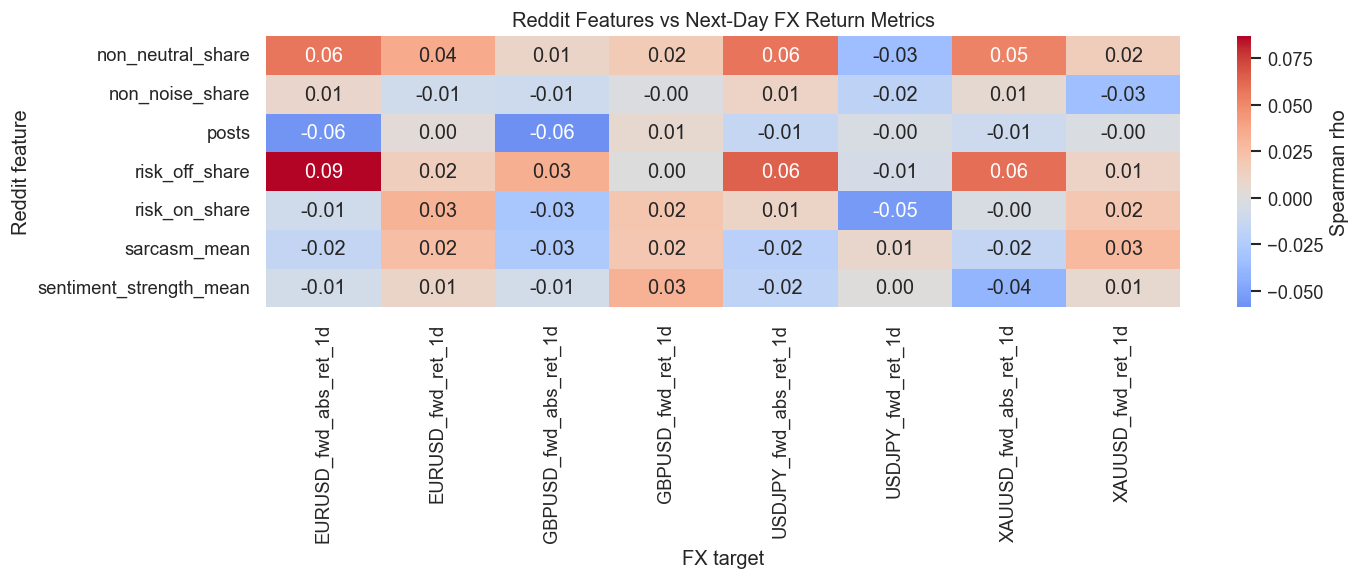

In [19]:
pivot_corr = corr_df.pivot(index="feature", columns="target", values="spearman_rho")
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Reddit Features vs Next-Day FX Return Metrics")
ax.set_xlabel("FX target")
ax.set_ylabel("Reddit feature")
plt.tight_layout()
plt.show()

**Correlations with next-day FX metrics exist, but effect sizes are small.**

The strongest rank association is between `risk_off_share` and next-day absolute EURUSD return (Spearman $\rho \approx 0.087$, $p<0.001$), with similar but smaller effects for USDJPY and XAUUSD volatility.
Most directional next-day return correlations are near zero, indicating signal is more about volatility regime than return sign at this stage.
This motivates hypothesis tests on high-vs-low Reddit risk regimes rather than relying on raw correlation magnitude alone.

## 10) Hypothesis Tests: High-Risk-Discussion Days vs Low-Risk-Discussion Days

We compare next-day absolute returns on top-quartile vs bottom-quartile `risk_off_share` days using Mann-Whitney U and Welch's t-test.

In [20]:
q1 = aligned["risk_off_share"].quantile(0.25)
q3 = aligned["risk_off_share"].quantile(0.75)
low = aligned[aligned["risk_off_share"] <= q1]
high = aligned[aligned["risk_off_share"] >= q3]

test_targets = [c for c in aligned.columns if c.endswith("_fwd_abs_ret_1d")]

def cohens_d(a: pd.Series, b: pd.Series) -> float:
    a = a.dropna().values
    b = b.dropna().values
    na, nb = len(a), len(b)
    sa2, sb2 = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1) * sa2 + (nb - 1) * sb2) / (na + nb - 2))
    return (np.mean(b) - np.mean(a)) / pooled if pooled > 0 else np.nan

hyp_rows = []
for t in test_targets:
    a = low[t].dropna()
    b = high[t].dropna()
    u_stat, p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")
    t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)
    hyp_rows.append({
        "target": t,
        "low_mean": a.mean(),
        "high_mean": b.mean(),
        "pct_diff_high_vs_low": (b.mean() / a.mean() - 1) * 100 if a.mean() != 0 else np.nan,
        "cohens_d": cohens_d(a, b),
        "p_mannwhitney": p_mw,
        "p_welch_t": p_t,
    })

hyp_df = pd.DataFrame(hyp_rows).sort_values("p_mannwhitney")
display(hyp_df)

,target,low_mean,high_mean,pct_diff_high_vs_low,cohens_d,p_mannwhitney,p_welch_t
0,EURUSD_fwd_abs_ret_1d,0.002885,0.003573,23.869445,0.222142,0.001801,0.000648
2,USDJPY_fwd_abs_ret_1d,0.003753,0.004315,14.982566,0.141307,0.012574,0.020263
3,XAUUSD_fwd_abs_ret_1d,0.005845,0.007038,20.396921,0.191409,0.019256,0.003220
1,GBPUSD_fwd_abs_ret_1d,0.003264,0.003812,16.778769,0.156500,0.172010,0.019509


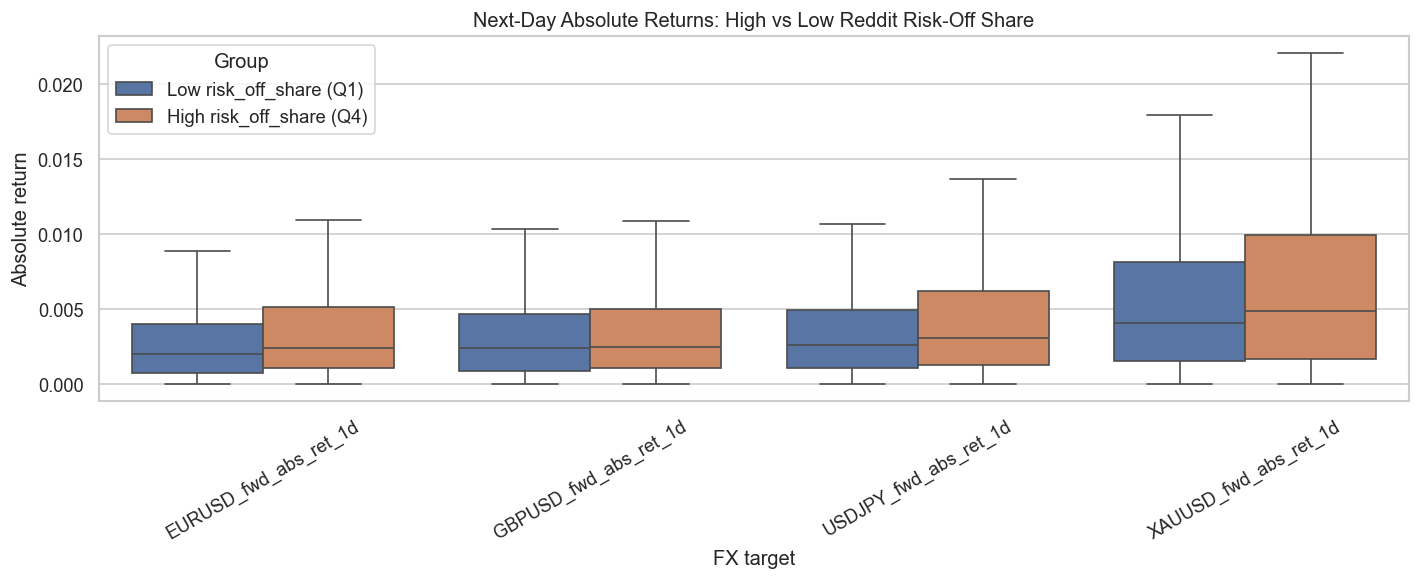

In [21]:
box_df = pd.concat([
    low.assign(group="Low risk_off_share (Q1)")[test_targets + ["group"]],
    high.assign(group="High risk_off_share (Q4)")[test_targets + ["group"]],
])
plot_df = box_df.melt(id_vars="group", value_vars=test_targets, var_name="target", value_name="fwd_abs_ret")

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=plot_df, x="target", y="fwd_abs_ret", hue="group", ax=ax, showfliers=False)
ax.set_title("Next-Day Absolute Returns: High vs Low Reddit Risk-Off Share")
ax.set_xlabel("FX target")
ax.set_ylabel("Absolute return")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Group")
plt.tight_layout()
plt.show()

**High risk-off discussion days are associated with higher next-day FX/metal volatility.**

Across EURUSD, USDJPY, and XAUUSD, the high `risk_off_share` quartile shows higher mean next-day absolute returns than the low quartile, with Mann-Whitney p-values below 0.05.
Effect sizes are small-to-moderate (Cohen's $d$ around 0.14 to 0.22), so this is not a large effect but it is directionally consistent.
This supports using volatility-aware targets for later modeling while keeping expectations realistic about signal strength.

## 11) Multiple-Testing Control and Lead/Lag Diagnostic

We control false discoveries (Benjamini-Hochberg) and test whether risk-off discussion leads, lags, or coincides with FX volatility.

In [22]:
# Benjamini-Hochberg FDR control
corr_fdr = corr_df.sort_values("p_value").reset_index(drop=True).copy()
m = len(corr_fdr)
corr_fdr["rank"] = np.arange(1, m + 1)
corr_fdr["bh_crit"] = corr_fdr["rank"] / m * 0.05
corr_fdr["bh_significant"] = corr_fdr["p_value"] <= corr_fdr["bh_crit"]

display(corr_fdr.head(12))
print("FDR-significant tests:", int(corr_fdr["bh_significant"].sum()), "out of", m)

,feature,target,spearman_rho,p_value,abs_rho,rank,bh_crit,bh_significant
0,risk_off_share,EURUSD_fwd_abs_ret_1d,0.086907,0.000617,0.086907,1,0.000893,True
1,risk_off_share,USDJPY_fwd_abs_ret_1d,0.064199,0.011495,0.064199,2,0.001786,False
2,risk_off_share,XAUUSD_fwd_abs_ret_1d,0.059634,0.018914,0.059634,3,0.002679,False
3,posts,GBPUSD_fwd_abs_ret_1d,-0.058843,0.020556,0.058843,4,0.003571,False
4,non_neutral_share,USDJPY_fwd_abs_ret_1d,0.057395,0.023886,0.057395,5,0.004464,False
5,non_neutral_share,EURUSD_fwd_abs_ret_1d,0.056960,0.024974,0.056960,6,0.005357,False
6,posts,EURUSD_fwd_abs_ret_1d,-0.056164,0.027076,0.056164,7,0.006250,False
7,risk_on_share,USDJPY_fwd_ret_1d,-0.054208,0.032898,0.054208,8,0.007143,False
8,non_neutral_share,XAUUSD_fwd_abs_ret_1d,0.052656,0.038249,0.052656,9,0.008036,False
9,sentiment_strength_mean,XAUUSD_fwd_abs_ret_1d,-0.040449,0.111533,0.040449,10,0.008929,False


FDR-significant tests: 1 out of 56


In [23]:
# Lead/lag correlation with basket volatility
ret_cols = [c for c in aligned.columns if c.endswith("_ret_1d")]
fwd_abs_cols = [c for c in aligned.columns if c.endswith("_fwd_abs_ret_1d")]

aligned["same_day_abs_basket"] = aligned[ret_cols].abs().mean(axis=1)
aligned["next_day_abs_basket"] = aligned[fwd_abs_cols].mean(axis=1)

lag_rows = []
for lag in range(-3, 4):
    y = aligned["same_day_abs_basket"].shift(-lag)
    rho, p = stats.spearmanr(aligned["risk_off_share"], y, nan_policy="omit")
    lag_rows.append({"lag_days": lag, "spearman_rho": rho, "p_value": p})

lag_df = pd.DataFrame(lag_rows).sort_values("lag_days")
display(lag_df)

,lag_days,spearman_rho,p_value
0,-3,0.071996,4.622977e-03
1,-2,0.114211,6.692011e-06
2,-1,0.187865,9.196781e-14
3,0,0.156135,6.490731e-10
4,1,0.053775,3.438174e-02
5,2,0.057029,2.489307e-02
6,3,0.069422,6.319656e-03


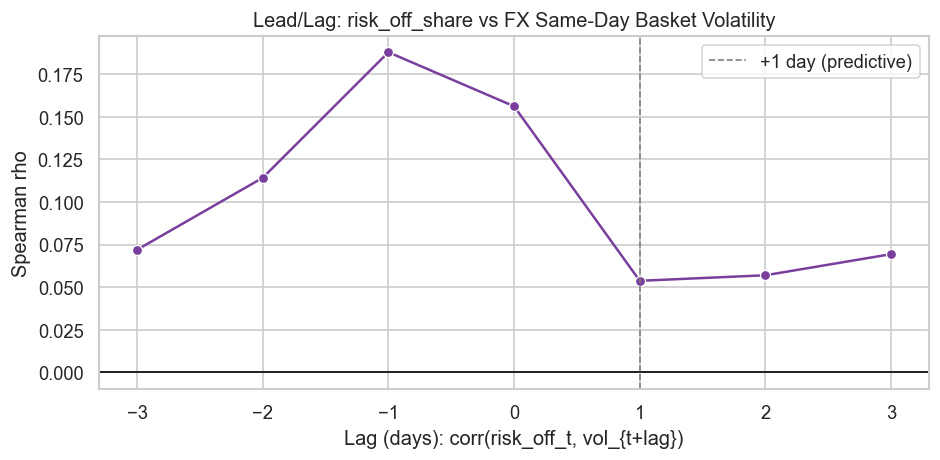

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=lag_df, x="lag_days", y="spearman_rho", marker="o", ax=ax, color="#7a3e9d")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(1, color="gray", linestyle="--", linewidth=1, label="+1 day (predictive)")
ax.set_title("Lead/Lag: risk_off_share vs FX Same-Day Basket Volatility")
ax.set_xlabel("Lag (days): corr(risk_off_t, vol_{t+lag})")
ax.set_ylabel("Spearman rho")
ax.legend()
plt.tight_layout()
plt.show()

**After robustness checks, only a narrow slice of correlation signal survives strict multiple-testing control.**

Benjamini-Hochberg control leaves 1 robust result: `risk_off_share` vs next-day EURUSD absolute return remains significant.
The broader pattern still points to volatility linkage, but most pairwise findings are weak and likely sensitive to multiple comparisons.
This implies downstream modeling should treat Reddit features as low-signal, incremental predictors rather than primary drivers.

**Lead/lag diagnostics suggest a mixed causal picture, not clean one-day predictiveness.**

The strongest association appears at lag `-1`, where FX volatility tends to precede higher Reddit risk-off share the next day, consistent with reactive discussion behavior.
At predictive lag `+1`, the correlation is positive but materially smaller, indicating some forward information may exist but is modest.
For later modeling, this argues for careful anti-leakage design and evaluation against strong naive volatility baselines.

## 12) Pre-Model Statistical Verdict

| # | Test | Result | Practical Meaning |
|---|------|--------|-------------------|
| 1 | Spearman scan (56 pairs) | 9 nominally significant at $p<0.05$, max $|\rho|\approx0.087$ | Signal exists but weak in magnitude. |
| 2 | FDR correction (BH) | 1/56 remains significant | Most raw correlations are not robust to multiplicity. |
| 3 | High vs low risk-off days (Mann-Whitney) | EURUSD, USDJPY, XAUUSD next-day absolute returns significantly higher in Q4 vs Q1 | Reddit risk-off intensity is more linked to volatility regime than direction. |
| 4 | Effect size check (Cohen's $d$) | Roughly 0.14 to 0.22 | Effects are small-to-moderate; expect incremental edge only. |
| 5 | Lead/lag diagnostic | Strongest at lag -1, weaker at +1 | Reddit appears partly reactive to market stress; predictive content is modest. |
| 6 | Data sufficiency | 1,549 aligned daily observations across 2021-2025 | Adequate for baseline statistical validation before modeling. |